In [11]:
"""
==============================================================
GENETIC ALGORITHM FOR TSP
Genotype–Phenotype Illustration Version
==============================================================

GENOTYPE  : permutation of city indices
PHENOTYPE : decoded travel route
FITNESS   : inverse tour cost (scaled)

Pipeline:
Initialize → Decode → Evaluate → Select → Crossover → Mutate
→ Elitism → Repeat → Optimal Tour
==============================================================
"""

import numpy as np
import matplotlib.pyplot as plt
import random

# -------------------------------------------------------------
# 1️⃣ REPRODUCIBILITY
# Fix randomness so experiments are repeatable
# -------------------------------------------------------------
np.random.seed(42)
random.seed(42)

# -------------------------------------------------------------
# 2️⃣ PROBLEM DEFINITION (TSP WORLD)
# Cities = environment where phenotype exists
# -------------------------------------------------------------
cities_coords = np.array([
    [0, 0],   # A
    [1, 3],   # B
    [4, 2],   # C
    [3, 0],   # D
    [1, 4]    # E

 ])

city_labels = ['A', 'B', 'C', 'D','E']
n_cities = len(cities_coords)

# Distance matrix (phenotype evaluation space)
dist_matrix = np.linalg.norm(
    cities_coords[:, None, :] - cities_coords[None, :, :],
    axis=2
)



In [14]:
dist_matrix


array([[0.        , 3.16227766, 4.47213595, 3.        , 4.12310563],
       [3.16227766, 0.        , 3.16227766, 3.60555128, 1.        ],
       [4.47213595, 3.16227766, 0.        , 2.23606798, 3.60555128],
       [3.        , 3.60555128, 2.23606798, 0.        , 4.47213595],
       [4.12310563, 1.        , 3.60555128, 4.47213595, 0.        ]])

In [12]:

# -------------------------------------------------------------
# 3️⃣ GA PARAMETERS
# Evolution control variables
# -------------------------------------------------------------
population_size = 30
generations = 40
mutation_rate = 0.25
elite_size = 1


# -------------------------------------------------------------
# 4️⃣ GENOTYPE CREATION
# Chromosome = permutation of cities
# Normalize so city A (0) always first
# -------------------------------------------------------------
def normalize(chrom):
    idx = chrom.index(0)
    return chrom[idx:] + chrom[:idx]


def create_random_chromosome():
    chrom = list(range(n_cities))
    random.shuffle(chrom)
    return normalize(chrom)



In [15]:

# -------------------------------------------------------------
# 5️⃣ GENOTYPE → PHENOTYPE DECODING
# Converts genetic encoding into real tour
# -------------------------------------------------------------
def decode(chrom):
    return [city_labels[i] for i in chrom] + [city_labels[chrom[0]]]


# -------------------------------------------------------------
# 6️⃣ PHENOTYPE EVALUATION (COST)
# Computes physical tour length
# -------------------------------------------------------------
def calculate_cost(chrom):
    cost = 0
    for i in range(n_cities):
        cost += dist_matrix[chrom[i],
                            chrom[(i + 1) % n_cities]]
    return cost




In [16]:

# -------------------------------------------------------------
# 7️⃣ FITNESS SCALING
# Stable alternative to 1/cost
# Prevents selection explosion
# -------------------------------------------------------------
def calculate_fitness(costs):
    max_cost = max(costs)
    return [max_cost - c + 1e-6 for c in costs]


# -------------------------------------------------------------
# 8️⃣ SELECTION (Tournament)
# Survival of the fittest
# -------------------------------------------------------------
def tournament_selection(population, fitnesses, k=3):
    selected = random.sample(range(len(population)), k)
    best = max(selected, key=lambda i: fitnesses[i])
    return population[best][:]


# -------------------------------------------------------------
# 9️⃣ ORDER CROSSOVER (OX)
# Permutation-safe recombination
# Preserves city order information
# -------------------------------------------------------------
def order_crossover(p1, p2):
    size = len(p1)
    start, end = sorted(random.sample(range(size), 2))

    child = [None] * size
    child[start:end] = p1[start:end]

    idx = end % size
    for gene in p2:
        if gene not in child:
            while child[idx] is not None:
                idx = (idx + 1) % size
            child[idx] = gene
            idx = (idx + 1) % size

    return normalize(child)


# -------------------------------------------------------------
# 🔟 MUTATION (Swap Mutation)
# Introduces diversity into genotype space
# -------------------------------------------------------------
def mutate(chrom):
    if random.random() < mutation_rate:
        i, j = random.sample(range(n_cities), 2)
        chrom[i], chrom[j] = chrom[j], chrom[i]
    return normalize(chrom)



In [17]:

# -------------------------------------------------------------
# 1️⃣1️⃣ VISUALIZATION
# Shows phenotype (actual route)
# -------------------------------------------------------------
def plot_tsp(tour, title):
    plt.figure(figsize=(7,5))
    plt.title(title)

    plt.scatter(cities_coords[:,0], cities_coords[:,1], s=150)

    for i, label in enumerate(city_labels):
        plt.text(cities_coords[i,0]+0.1,
                 cities_coords[i,1]+0.1,
                 label, fontsize=12)

    route = tour + [tour[0]]

    for i in range(len(route)-1):
        p1 = cities_coords[route[i]]
        p2 = cities_coords[route[i+1]]
        plt.plot([p1[0], p2[0]],
                 [p1[1], p2[1]], linewidth=2)

    plt.grid(True)
    plt.show()



In [18]:

# -------------------------------------------------------------
# 1️⃣2️⃣ INITIAL POPULATION
# Random solutions (genotype space)
# -------------------------------------------------------------
population = [create_random_chromosome()
              for _ in range(population_size)]

best_cost_overall = float('inf')
best_chrom_overall = None
history = []



In [19]:
population

[[0, 1, 4, 2, 3],
 [0, 4, 1, 3, 2],
 [0, 2, 4, 3, 1],
 [0, 1, 2, 3, 4],
 [0, 2, 3, 4, 1],
 [0, 4, 2, 3, 1],
 [0, 4, 2, 3, 1],
 [0, 4, 3, 1, 2],
 [0, 2, 1, 4, 3],
 [0, 3, 2, 1, 4],
 [0, 1, 4, 2, 3],
 [0, 3, 1, 4, 2],
 [0, 2, 1, 3, 4],
 [0, 4, 1, 3, 2],
 [0, 1, 3, 2, 4],
 [0, 2, 4, 1, 3],
 [0, 4, 1, 3, 2],
 [0, 2, 1, 3, 4],
 [0, 1, 4, 3, 2],
 [0, 4, 3, 1, 2],
 [0, 2, 4, 1, 3],
 [0, 3, 1, 4, 2],
 [0, 4, 3, 2, 1],
 [0, 3, 1, 4, 2],
 [0, 1, 2, 4, 3],
 [0, 1, 2, 3, 4],
 [0, 1, 2, 4, 3],
 [0, 4, 1, 2, 3],
 [0, 1, 4, 3, 2],
 [0, 1, 2, 3, 4]]

In [20]:

# -------------------------------------------------------------
# 1️⃣3️⃣ EVOLUTION LOOP
# Core GA lifecycle
# -------------------------------------------------------------
for gen in range(generations + 1):

    costs = [calculate_cost(ch) for ch in population]
    fitnesses = calculate_fitness(costs)

    best_idx = np.argmax(fitnesses)
    best_cost = costs[best_idx]
    best_chrom = population[best_idx]

    # Save global best (ELITISM MEMORY)
    if best_cost < best_cost_overall:
        best_cost_overall = best_cost
        best_chrom_overall = best_chrom[:]

    history.append(best_cost_overall)

    print(f"\n===== GENERATION {gen} =====")
    for i, ch in enumerate(population):
        print(
            f"Ind {i+1}: "
            f"Genotype {ch} → "
            f"Phenotype {'→'.join(decode(ch))} "
            f"| Cost {costs[i]:.2f}"
        )

    if gen == generations:
        break

    # ---------------- Evolution ----------------
    new_population = []

    # ✅ ELITISM (keep best solution)
    new_population.append(best_chrom[:])

    while len(new_population) < population_size:
        p1 = tournament_selection(population, fitnesses)
        p2 = tournament_selection(population, fitnesses)

        child = order_crossover(p1, p2)
        child = mutate(child)

        new_population.append(child)

    population = new_population





===== GENERATION 0 =====
Ind 1: Genotype [0, 1, 4, 2, 3] → Phenotype A→B→E→C→D→A | Cost 13.00
Ind 2: Genotype [0, 4, 1, 3, 2] → Phenotype A→E→B→D→C→A | Cost 15.44
Ind 3: Genotype [0, 2, 4, 3, 1] → Phenotype A→C→E→D→B→A | Cost 19.32
Ind 4: Genotype [0, 1, 2, 3, 4] → Phenotype A→B→C→D→E→A | Cost 17.16
Ind 5: Genotype [0, 2, 3, 4, 1] → Phenotype A→C→D→E→B→A | Cost 15.34
Ind 6: Genotype [0, 4, 2, 3, 1] → Phenotype A→E→C→D→B→A | Cost 16.73
Ind 7: Genotype [0, 4, 2, 3, 1] → Phenotype A→E→C→D→B→A | Cost 16.73
Ind 8: Genotype [0, 4, 3, 1, 2] → Phenotype A→E→D→B→C→A | Cost 19.84
Ind 9: Genotype [0, 2, 1, 4, 3] → Phenotype A→C→B→E→D→A | Cost 16.11
Ind 10: Genotype [0, 3, 2, 1, 4] → Phenotype A→D→C→B→E→A | Cost 13.52
Ind 11: Genotype [0, 1, 4, 2, 3] → Phenotype A→B→E→C→D→A | Cost 13.00
Ind 12: Genotype [0, 3, 1, 4, 2] → Phenotype A→D→B→E→C→A | Cost 15.68
Ind 13: Genotype [0, 2, 1, 3, 4] → Phenotype A→C→B→D→E→A | Cost 19.84
Ind 14: Genotype [0, 4, 1, 3, 2] → Phenotype A→E→B→D→C→A | Cost 15.44
Ind


========== FINAL RESULT ==========
Optimal Tour: A → B → E → C → D → A
Minimum Cost: 13.004


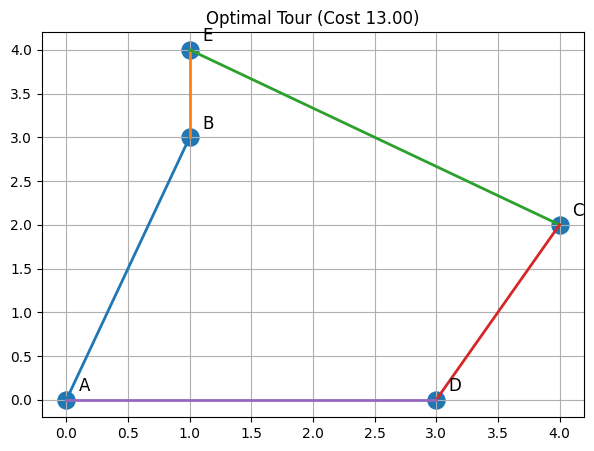

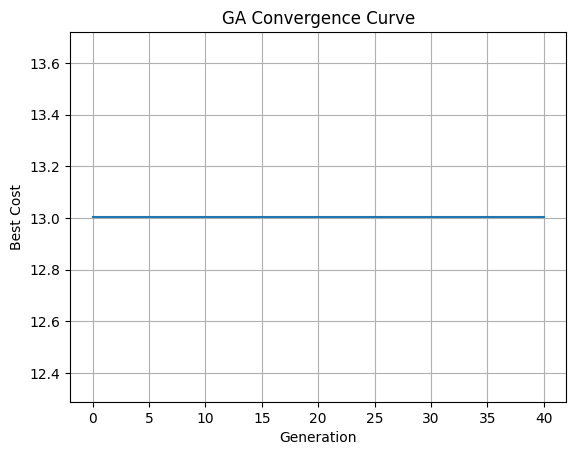

In [21]:

# -------------------------------------------------------------
# 1️⃣4️⃣ RESULTS
# Best phenotype discovered
# -------------------------------------------------------------
print("\n========== FINAL RESULT ==========")
print("Optimal Tour:",
      " → ".join(decode(best_chrom_overall)))
print("Minimum Cost:", round(best_cost_overall, 3))

plot_tsp(best_chrom_overall,
         f"Optimal Tour (Cost {best_cost_overall:.2f})")


# -------------------------------------------------------------
# 1️⃣5️⃣ CONVERGENCE VISUALIZATION
# Shows evolution learning behaviour
# -------------------------------------------------------------
plt.figure()
plt.plot(history)
plt.title("GA Convergence Curve")
plt.xlabel("Generation")
plt.ylabel("Best Cost")
plt.grid(True)
plt.show()